NYC Airbnb Room Type Classification

Dataset: [New York City Airbnb Open Data](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data) (Kaggle)

Goal: Predict the room_type of an Airbnb listing (Entire home/apt, Private room, or Shared room) using listing attributes such as price, location, availability, and review activity.

What this notebook covers (the full ML lifecycle):

1. Problem framing & data loading
2. Exploratory Data Analysis (EDA) — univariate, bivariate, skewness, outliers
3. Data cleaning & feature engineering
4. Train / test split
5. Preprocessing with ColumnTransformer + Pipeline
6. Baseline model
7. Multiple candidate algorithms (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting)
8. Model comparison (cross-validation)
9. Hyperparameter tuning of the best model
10. Final evaluation on the untouched test set
11. Feature importance
12. Saving the final pipeline (model artifact)
13. Conclusion & next steps

1. Import Libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv('AB_NYC_2019.csv')
df.head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129
6,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,2017-10-05,0.40,1,0
7,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Hell's Kitchen,40.76489,-73.98493,Private room,79,2,430,2019-06-24,3.47,1,220
8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80178,-73.96723,Private room,79,2,118,2017-07-21,0.99,1,0
9,5238,Cute & Cozy Lower East Side 1 bdrm,7549,Ben,Manhattan,Chinatown,40.71344,-73.99037,Entire home/apt,150,1,160,2019-06-09,1.33,4,188


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,48895.0,NaN,NaN,NaN,19017143.23618,10983108.38561,2539.0,9471945.0,19677284.0,29152178.5,36487245.0
name,48879,47905,Hillside Hotel,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,48895.0,NaN,NaN,NaN,67620010.64661,78610967.032667,2438.0,7822033.0,30793816.0,107434423.0,274321313.0
host_name,48874,11452,Michael,417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,48895,5,Manhattan,21661,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,48895,221,Williamsburg,3920,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,48895.0,NaN,NaN,NaN,40.728949,0.05453,40.49979,40.6901,40.72307,40.763115,40.91306
longitude,48895.0,NaN,NaN,NaN,-73.95217,0.046157,-74.24442,-73.98307,-73.95568,-73.936275,-73.71299
room_type,48895,3,Entire home/apt,25409,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,48895.0,NaN,NaN,NaN,152.720687,240.15417,0.0,69.0,106.0,175.0,10000.0


In [5]:
df.shape

(48895, 16)

3. Exploratory Data Analysis (EDA)

We explore the data in the standard order every ML engineer follows:

* Missing values
* Univariate analysis (one variable at a time — distributions, skewness)
* Bivariate analysis (relationship between features and the target)
* Correlation between numeric features
* Outlier inspection

In [6]:
### 3.1  Missing value 

df.isna().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

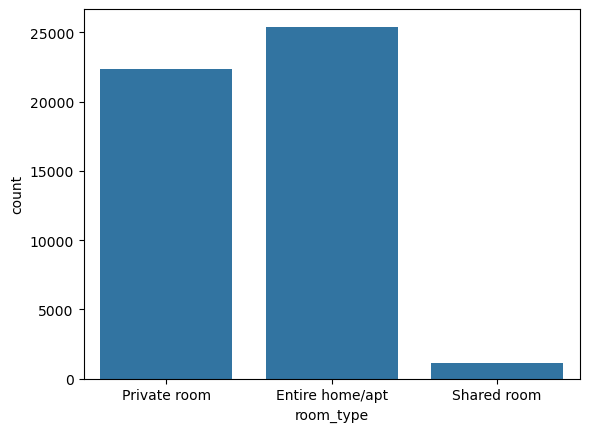

In [7]:
### 3.2  Target Variable — room_type

df['room_type'].value_counts()

sns.countplot(x='room_type',data=df)
plt.show()

the classes imbalanced -> shared room is a small minority 

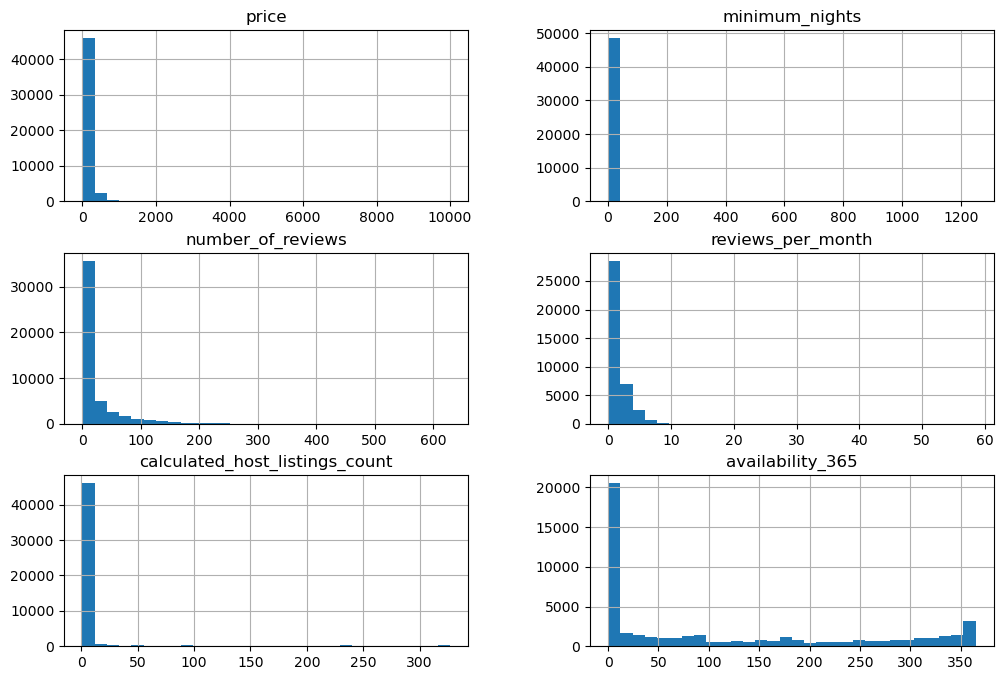

In [8]:
### 3.3  Univariate analysis - Numeric features

numeric_col=['price','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365']

df[numeric_col].hist(bins=30,figsize=(12,8))
plt.show()


<Axes: xlabel='neighbourhood_group', ylabel='count'>

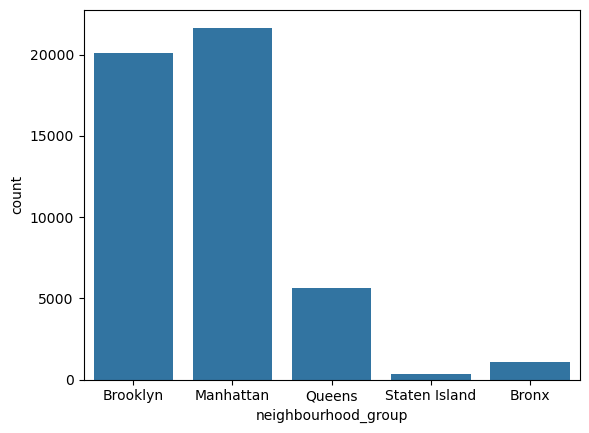

In [9]:
#### 3.4  Univariant analysis - categorical Features

sns.countplot(data=df,x='neighbourhood_group')

<Axes: xlabel='room_type', ylabel='price'>

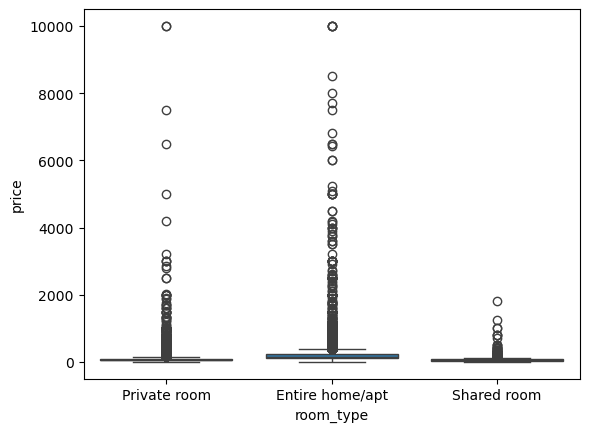

In [10]:
### 3.5 Bivariant Analysis - Feature vs target 
sns.boxplot(x='room_type',y='price',data=df)

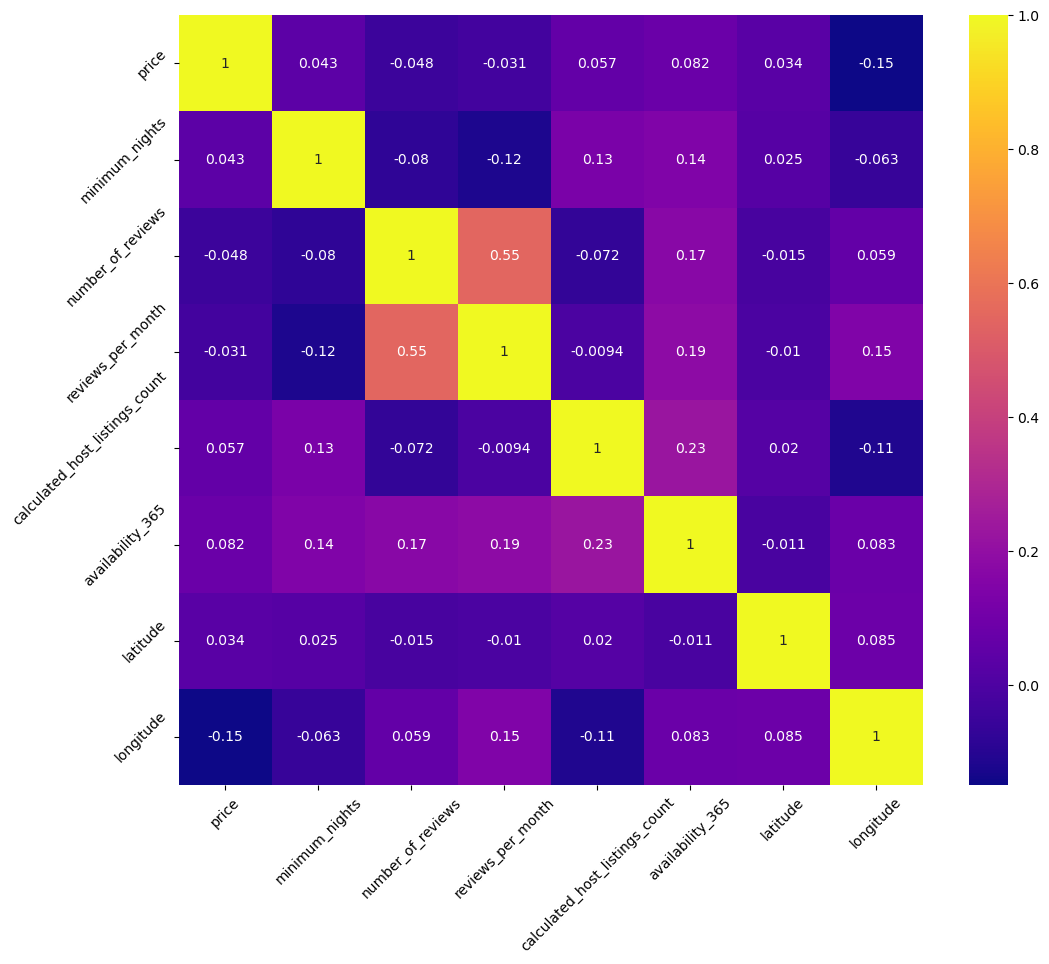

In [11]:
### 3.6 Correlation Between Numeric Feature : 

corr=df[numeric_col+['latitude','longitude']].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr,annot=True,cmap='plasma')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

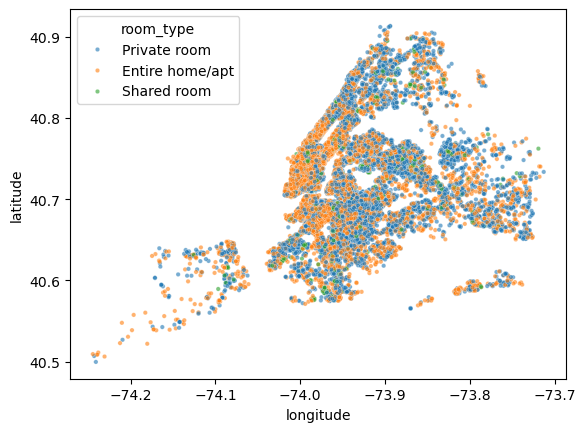

In [12]:
### 3.7 Geographic Distribution (Bonus Visual)
sns.scatterplot(x='longitude',y='latitude',data=df,hue='room_type',alpha=0.6,s=10)
plt.show()

4. Data Cleaning & Feature Engineering

Steps:

1. Drop columns that are pure identifiers or free text and carry no generalizable signal for a tabular model (id, name, host_id, host_name, last_review).
2. Fill missing reviews_per_month with 0 (no reviews yet).
3. Cap extreme outliers in price and minimum_nights using percentile clipping, so a handful of data-entry errors (e.g. $10,000/4.  night, 1,250 minimum nights) don't distort the model.
5. Separate features (X) from the target (y).

In [13]:
## 1.  drop columns that dont help us. 
df_clean=df.drop(columns=['id','name','host_id','host_name','last_review'])

### 2. No review yet --> 0 review per month, not missing
df_clean['reviews_per_month']=df_clean['reviews_per_month'].fillna(0)


In [14]:
## 3 . Cap  Extreme outlier instead of deleting rows. 

price_cap=df_clean['price'].quantile(0.99)
night_cap=df_clean['minimum_nights'].quantile(0.99)

df_clean=df_clean[df_clean['price']<price_cap]
df_clean=df_clean[df_clean['minimum_nights']<night_cap]

In [15]:
df_clean

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...
48890,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,0.00,2,9
48891,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,0.00,2,36
48892,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,0.00,1,27
48893,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,0.00,6,2


In [16]:
X=df_clean.drop(columns=['room_type'])
y=df_clean['room_type']

5. Train / Test Split

We hold out 20% of the data as a test set that is never touched during model selection or tuning — it is only used once, at the very end, to report the final, honest performance. stratify=y keeps the same class proportions in both splits, which matters because the target is imbalanced.

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42,stratify=y)  

6. Preprocessing: ColumnTransformer + Pipeline

Production ML code should never manually transform train/test data with separate lines — it's error-prone and leaks information. Instead we build a single, reusable ColumnTransformer:

* **Numeric features** → median imputation + standard scaling
* **Categorical features** → most-frequent imputation + one-hot encoding

This transformer will be the first step of every model pipeline below, so preprocessing is learned only on training data and applied consistently everywhere (no data leakage).

In [18]:
df_clean[numeric_col].skew()

price                             2.234027
minimum_nights                    2.297930
number_of_reviews                 3.666398
reviews_per_month                 3.283871
calculated_host_listings_count    7.910731
availability_365                  0.780236
dtype: float64

In [19]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import StandardScaler,OneHotEncoder,PowerTransformer
from sklearn.compose import ColumnTransformer


In [20]:
numeric_col=['price','minimum_nights','number_of_reviews','reviews_per_month'
,'calculated_host_listings_count','availability_365','latitude','longitude']

categorical_col=['neighbourhood_group','neighbourhood']

### 1. Pipeline -> for numeric columns :
numeric_pipeline=Pipeline(steps=[
    ('impute',SimpleImputer(strategy='median')),
    ('scale',StandardScaler())
])

### 2. pipeline --> categorical columns :
categorical_pipeline=Pipeline(steps=[
    ('impute',SimpleImputer(strategy='most_frequent')),
    ('encode',OneHotEncoder(handle_unknown='ignore'))
])

preprocessor=ColumnTransformer(transformers=[
    ('numerical',numeric_pipeline,numeric_col),
    ('categorical',categorical_pipeline,categorical_col)
])

preprocessor

,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [21]:
df_clean['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

7. Trying Multiple Algorithms

We now compare several models, each wrapped in its own pipeline with the same preprocessor. We evaluate each with 3-fold stratified cross-validation on the training set (never touching the test set yet), so the comparison is fair and robust.

Models tried:

1. Logistic Regression — simple, interpretable linear baseline
2. Decision Tree — a single non-linear model, prone to overfitting
3. Random Forest — an ensemble of trees, usually a strong general-purpose model
4. Gradient Boosting — sequential ensemble, often the most accurate of the classics


**SMOTE (Synthetic Minority Oversampling).**

***for class IMbalance***

1. High chances of Overfitting.

2. Data Leakage

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.model_selection import cross_validate

In [23]:
from sklearn.model_selection import cross_val_score

#### class_weight= "Balanced" tells the models to pay more attention to the minority class or rare class (shared room)
# but the problem is GradientBoosting doesnot support class weight so we left it as it is. 

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])

    accuracy = cross_val_score(pipe, X_train, y_train, cv=3, scoring="accuracy")
    macrof1 = cross_val_score(pipe, X_train, y_train, cv=3, scoring="f1_macro")
    
    print(f"{name} -> Accuracy: {accuracy.mean():.3f}, F1: {macrof1.mean():.3f}")


Logistic Regression -> Accuracy: 0.673, F1: 0.533
Decision Tree -> Accuracy: 0.785, F1: 0.657
Random Forest -> Accuracy: 0.851, F1: 0.713
Gradient Boosting -> Accuracy: 0.851, F1: 0.705


**8. Hyperparameter Tuning**

We pick the best-performing model from the comparison above (whichever one that turns out to be) and search over its key hyperparameters using RandomizedSearchCV (cheaper than an exhaustive grid search, while still exploring the space well). We keep optimizing for macro-F1 since the classes are imbalanced.

In [24]:
from sklearn.model_selection import RandomizedSearchCV

best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced'))
])

param_distribution = {
    "classifier__n_estimators": [100, 200, 150, 300],
    "classifier__max_depth": [8, 12, 15, 20, None],
    "classifier__min_samples_split": [2, 5, 10],
}

# Assign the search object to the variable 'search'
search = RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_distribution,
    n_iter=10,
    cv=3,
    scoring="f1_macro",
    random_state=42,
    n_jobs=-1 # Optional: uses all CPU cores to speed up the search
)

# Now fit the search object
search.fit(X_train, y_train)

,estimator,Pipeline(step...'balanced'))])
,param_distributions,"{'classifier__max_depth': [8, 12, ...], 'classifier__min_samples_split': [2, 5, ...], 'classifier__n_estimators': [100, 200, ...]}"
,n_iter,10
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [25]:
print("Best Parameter:",search.best_params_)
print("Best CV Macro -F1:",search.best_score_)

Best Parameter: {'classifier__n_estimators': 200, 'classifier__min_samples_split': 10, 'classifier__max_depth': None}
Best CV Macro -F1: 0.7370658325441376


**9. Final Evaluation on the Test Set**

This is the only time we touch the held-out test set. It gives us an honest estimate of how the final tuned model would perform on completely unseen listings.

In [26]:
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score
best_pipeline=search.best_estimator_

y_pred=best_pipeline.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test,y_pred)}")
print(f"F1 Score: {f1_score(y_test,y_pred,average="macro")}")

Accuracy Score: 0.8591299949418311
F1 Score: 0.7424944102112888


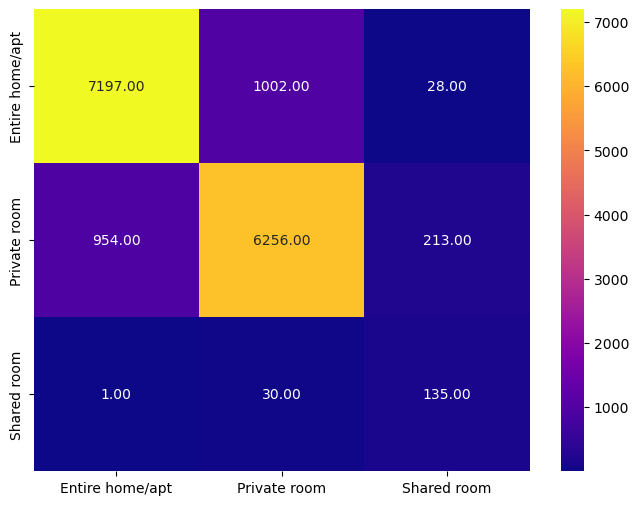

In [27]:
from seaborn import heatmap
plt.figure(figsize=(8,6))
sns,heatmap(confusion_matrix(y_pred,y_test),annot=True,cmap='plasma',fmt=".2f",
xticklabels=best_pipeline.classes_,yticklabels=best_pipeline.classes_)
plt.show()

**11. Saving the Final Model Artifact**

In production, the entire pipeline (preprocessing and model together) is serialized as a single artifact, so a new listing can be scored with one call no manual preprocessing required at inference time.

In [28]:
import joblib

joblib.dump(best_pipeline,"Model_Pipeline.pkl")

['Model_Pipeline.pkl']